# Chapter 2 Exercises

# Preparation

In [1]:
# Load packages
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.sampling_bars import tick_bar, volume_bar, dollar_bar

clean_data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(clean_data_path)

## 1. On a series of E-mini S&P 500 futures tick data:

### a. Form tick, volume, and dollar bars. Use the ETF trick to deal with the roll.

In [3]:
tick_df = tick_bar(df, tick_size=10)
volume_df = volume_bar(df, volume_size=1000)
dollar_df = dollar_bar(df, dollar_size=100000)

In [11]:
print(f"Size of tick_df: {len(tick_df)}")
print(f"Size of volume_df: {len(volume_df)}")
print(f"Size of dollar_df: {len(dollar_df)}")

Size of tick_df: 326559
Size of volume_df: 823145
Size of dollar_df: 903958


In [16]:
tick_df.tail()

,price,bid,ask,vol,dollar_vol
date,,,,,
2026-05-01 15:51:20,223.7427,223.73,223.75,125,27967.8375
2026-05-01 15:54:42,223.7300,223.73,223.74,100,22373.0000
2026-05-01 15:55:31,223.7300,223.72,223.73,100,22373.0000
2026-05-01 15:59:00,223.6100,223.60,223.62,100,22361.0000
2026-05-01 15:59:31,223.5750,223.57,223.58,132,29511.9000


In [15]:
volume_df.tail()

,price,bid,ask,vol,dollar_vol
date,,,,,
2026-05-01 15:57:53,223.6601,223.66,223.68,225,5.032352e+04
2026-05-01 15:59:02,223.6000,223.59,223.61,300,6.708000e+04
2026-05-01 15:59:20,223.5700,223.57,223.58,100,2.235700e+04
2026-05-01 15:59:32,223.5800,223.56,223.58,362,8.093596e+04
2026-05-01 16:00:00,223.5100,223.44,223.51,14243,3.183453e+06


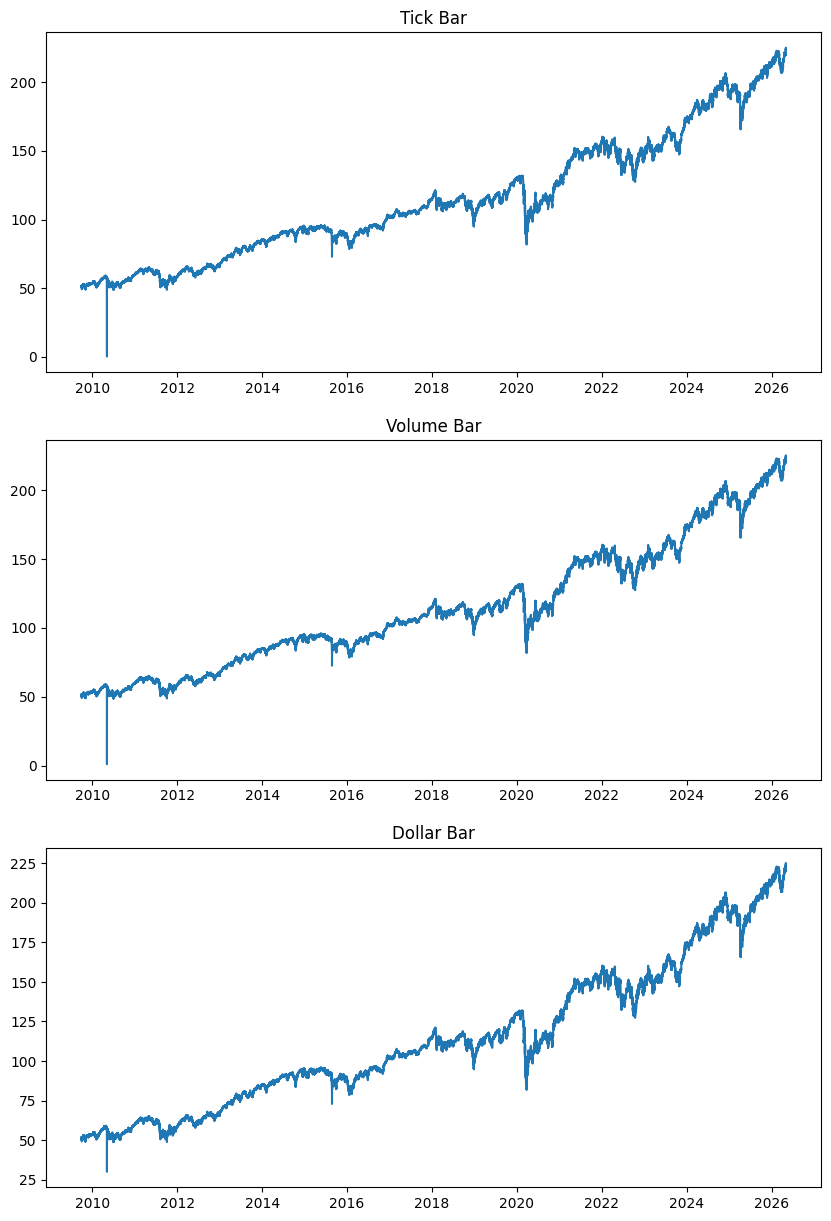

In [12]:
# plot the tick bar, volume bar, and dollar bar, along side with the original data
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs[0].plot(tick_df['price'])
axs[0].set_title('Tick Bar')
axs[1].plot(volume_df['price'])
axs[1].set_title('Volume Bar')
axs[2].plot(dollar_df['price'])
axs[2].set_title('Dollar Bar')
plt.show()

### b. Count the number of bars produced by tick, volume, and dollar bars on a weekly basis. Plot a time series of that bar count. What bar type produces the most stable weekly count? Why?

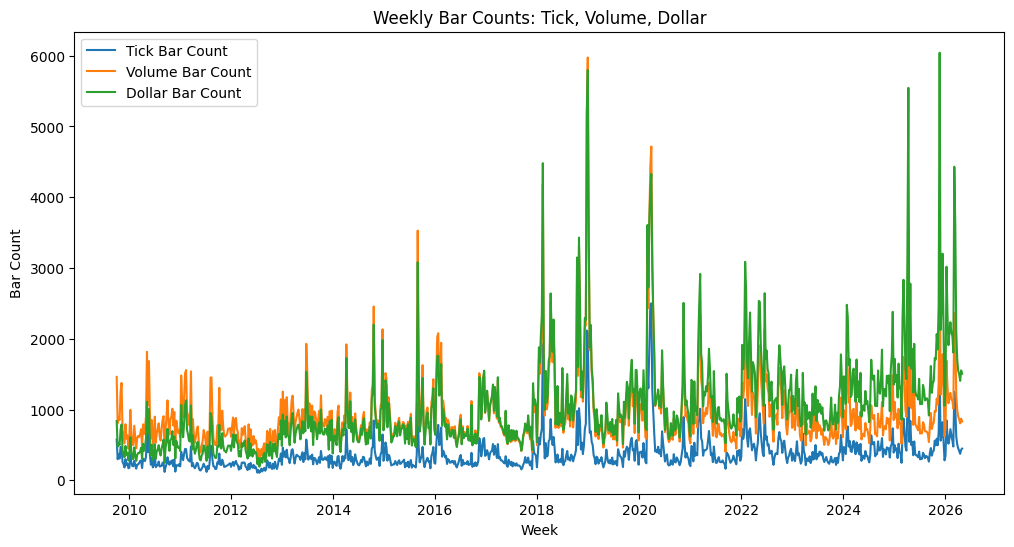

Tick bar count: date
2009-10-04    578
2009-10-11    299
2009-10-18    371
2009-10-25    308
2009-11-01    474
             ... 
2026-04-05    452
2026-04-12    414
2026-04-19    375
2026-04-26    432
2026-05-03    449
Freq: W-SUN, Length: 866, dtype: int64
Volume bar count: date
2009-10-04    1462
2009-10-11     808
2009-10-18     884
2009-10-25     852
2009-11-01    1249
              ... 
2026-04-05     904
2026-04-12     858
2026-04-19     805
2026-04-26     872
2026-05-03     832
Freq: W-SUN, Length: 866, dtype: int64
Dollar bar count: date
2009-10-04     839
2009-10-11     476
2009-10-18     529
2009-10-25     500
2009-11-01     716
              ... 
2026-04-05    1548
2026-04-12    1500
2026-04-19    1406
2026-04-26    1554
2026-05-03    1506
Freq: W-SUN, Length: 866, dtype: int64


In [21]:
# Count the number of bars produced by tick, volume, and dollar bars on a weekly basis.
tick_bar_count = tick_df.resample('W').size()
volume_bar_count = volume_df.resample('W').size()
dollar_bar_count = dollar_df.resample('W').size()

# Plot a time series of the bar counts on the same graph.
plt.figure(figsize=(12, 6))
plt.plot(tick_bar_count, label="Tick Bar Count")
plt.plot(volume_bar_count, label="Volume Bar Count")
plt.plot(dollar_bar_count, label="Dollar Bar Count")
plt.title('Weekly Bar Counts: Tick, Volume, Dollar')
plt.xlabel('Week')
plt.ylabel('Bar Count')
plt.legend()
plt.show()
# What bar type produces the most stable weekly count? Why?
print(f"Tick bar count: {tick_bar_count}")
print(f"Volume bar count: {volume_bar_count}")
print(f"Dollar bar count: {dollar_bar_count}")

In [20]:
# We measure the stability of the weekly count by the standard deviation of the bar count.
print(f"Tick bar count std: {tick_bar_count.std()}")
print(f"Volume bar count std: {volume_bar_count.std()}")
print(f"Dollar bar count std: {dollar_bar_count.std()}")
# The tick bar produces the most stable weekly count. This is because the tick bar is the most granular bar type, and therefore has the most bars.

Tick bar count std: 242.45275602861778
Volume bar count std: 538.8610042382837
Dollar bar count std: 682.1297923599768


### c. Compute the serial correlation of returns for the three bar types. What bar method has the lowest serial correlation?

In [39]:
# Compute log returns for the three bar types
tick_df['log_return'] = np.log(tick_df['price'] / tick_df['price'].shift(1))
volume_df['log_return'] = np.log(volume_df['price'] / volume_df['price'].shift(1))
dollar_df['log_return'] = np.log(dollar_df['price'] / dollar_df['price'].shift(1))

tick_df['linear_return'] = tick_df['price'] / tick_df['price'].shift(1) - 1
volume_df['linear_return'] = volume_df['price'] / volume_df['price'].shift(1) - 1
dollar_df['linear_return'] = dollar_df['price'] / dollar_df['price'].shift(1) - 1

# Compute the serial correlation of returns for the three bar types
tick_df['serial_correlation_log_return'] = tick_df['log_return'].autocorr()
volume_df['serial_correlation_log_return'] = volume_df['log_return'].autocorr()
dollar_df['serial_correlation_log_return'] = dollar_df['log_return'].autocorr()

tick_df['serial_correlation_linear_return'] = tick_df['linear_return'].autocorr()
volume_df['serial_correlation_linear_return'] = volume_df['linear_return'].autocorr()
dollar_df['serial_correlation_linear_return'] = dollar_df['linear_return'].autocorr()

# Print the serial correlation of returns for the three bar types
print(f"Tick bar log return serial correlation: {tick_df['serial_correlation_log_return'].mean()}")
print(f"Volume bar log return serial correlation: {volume_df['serial_correlation_log_return'].mean()}")
print(f"Dollar bar log return serial correlation: {dollar_df['serial_correlation_log_return'].mean()}")

print()

print(f"Tick bar linear return serial correlation: {tick_df['serial_correlation_linear_return'].mean()}")
print(f"Volume bar linear return serial correlation: {volume_df['serial_correlation_linear_return'].mean()}")
print(f"Dollar bar linear return serial correlation: {dollar_df['serial_correlation_linear_return'].mean()}")

# dollar bar has the lowest auto correlation. This is because the dollar bar is the most granular bar type, and therefore has the least amount of information.

Tick bar log return serial correlation: -0.4991363492355435
Volume bar log return serial correlation: -0.4863974799785227
Dollar bar log return serial correlation: -0.013240930049638265

Tick bar linear return serial correlation: -0.0038362454220307717
Volume bar linear return serial correlation: -0.02975239404646995
Dollar bar linear return serial correlation: -0.0021534816303473286


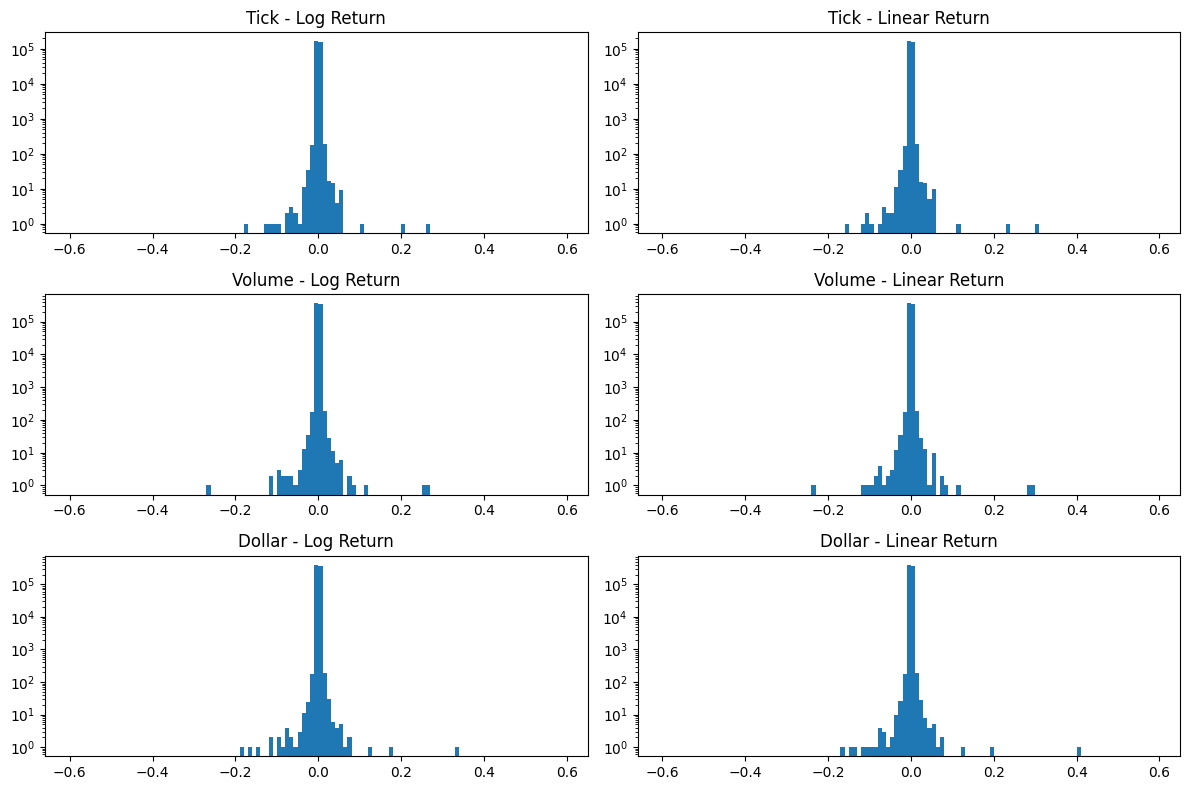

In [41]:
bins = np.arange(-0.6, 0.6, 0.01)

fig, ax = plt.subplots(3, 2, figsize=(12, 8))

# Log returns
ax[0, 0].hist(tick_df['log_return'], bins=bins)
ax[0, 0].set_title('Tick - Log Return')
ax[1, 0].hist(volume_df['log_return'], bins=bins)
ax[1, 0].set_title('Volume - Log Return')
ax[2, 0].hist(dollar_df['log_return'], bins=bins)
ax[2, 0].set_title('Dollar - Log Return')

# Linear returns
ax[0, 1].hist(tick_df['linear_return'], bins=bins)
ax[0, 1].set_title('Tick - Linear Return')
ax[1, 1].hist(volume_df['linear_return'], bins=bins)
ax[1, 1].set_title('Volume - Linear Return')
ax[2, 1].hist(dollar_df['linear_return'], bins=bins)
ax[2, 1].set_title('Dollar - Linear Return')

# Set yscale to log for all axes
for i in range(3):
    for j in range(2):
        ax[i, j].set_yscale('log')

fig.tight_layout()

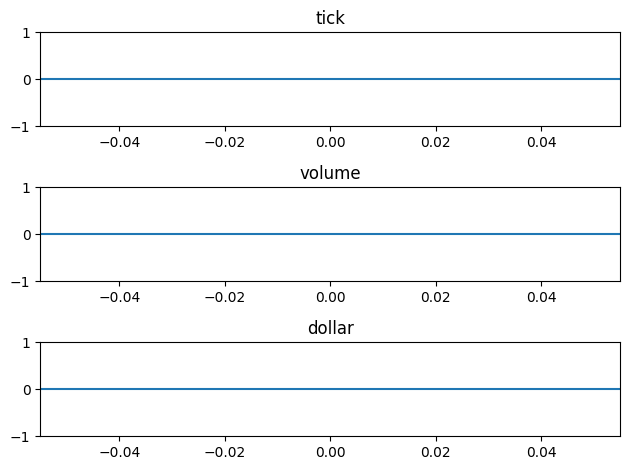

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(3,1)
plot_acf(tick_df['log_return'], lags=20, ax=ax[0], title='tick')
plot_acf(volume_df['log_return'], lags=20, ax=ax[1], title='volume')
plot_acf(dollar_df['log_return'], lags=20, ax=ax[2], title='dollar')
fig.tight_layout()

### d. Partition the bar series into monthly subsets. Compute the variance of returns for every subset of every bar type. Compute the variance of those variances. What method exhibits the smallest variance of variances?

In [ ]:
tick_log_return_monthly_variance = tick_df['log_return'].resample('ME').var()
volume_log_return_monthly_variance = volume_df['log_return'].resample('ME').var()
dollar_log_return_monthly_variance = dollar_df['log_return'].resample('ME').var()

tick_linear_return_monthly_variance = tick_df['linear_return'].resample('ME').var()
volume_linear_return_monthly_variance = volume_df['linear_return'].resample('ME').var()
dollar_linear_return_monthly_variance = dollar_df['linear_return'].resample('ME').var()

tick_log_return_monthly_variance_of_variance = tick_log_return_monthly_variance.var()
volume_log_return_monthly_variance_of_variance = volume_log_return_monthly_variance.var()
dollar_log_return_monthly_variance_of_variance = dollar_log_return_monthly_variance.var()

tick_linear_return_monthly_variance_of_variance = tick_linear_return_monthly_variance.var()
volume_linear_return_monthly_variance_of_variance = volume_linear_return_monthly_variance.var()
dollar_linear_return_monthly_variance_of_variance = dollar_linear_return_monthly_variance.var()

print(f"Tick log return monthly variance of variance: {tick_log_return_monthly_variance_of_variance}")
print(f"Volume log return monthly variance of variance: {volume_log_return_monthly_variance_of_variance}")
print(f"Dollar log return monthly variance of variance: {dollar_log_return_monthly_variance_of_variance}")

print()

print(f"Tick linear return monthly variance of variance: {tick_linear_return_monthly_variance_of_variance}")
print(f"Volume linear return monthly variance of variance: {volume_linear_return_monthly_variance_of_variance}")
print(f"Dollar linear return monthly variance of variance: {dollar_linear_return_monthly_variance_of_variance}")

Tick log return monthly variance of variance: 1.034807548727295e-05
Volume log return monthly variance of variance: 5.123211536625008e-07
Dollar log return monthly variance of variance: 4.659196215214209e-11

Tick linear return monthly variance of variance: 11.480229865986285
Volume linear return monthly variance of variance: 0.0008938846285513114
Dollar linear return monthly variance of variance: 5.987342801048639e-11


In [35]:
tick_log_return_monthly_variance.head()

date
2009-09-30    0.000001
2009-10-31    0.000002
2009-11-30    0.000003
2009-12-31    0.000002
2010-01-31    0.000002
Freq: ME, Name: log_return, dtype: float64

### e. Apply the Jarque-Bera normality test on returns from the three bar types. What method achieves the lowest test statistic?

In [50]:
from scipy.stats import jarque_bera

tick_log = tick_df['log_return'].replace([np.inf, -np.inf], np.nan).dropna()
volume_log = volume_df['log_return'].replace([np.inf, -np.inf], np.nan).dropna()
dollar_log = dollar_df['log_return'].replace([np.inf, -np.inf], np.nan).dropna()

tick_linear = tick_df['linear_return'].replace([np.inf, -np.inf], np.nan).dropna()
volume_linear = volume_df['linear_return'].replace([np.inf, -np.inf], np.nan).dropna()
dollar_linear = dollar_df['linear_return'].replace([np.inf, -np.inf], np.nan).dropna()

tick_log_return_jarque_bera = jarque_bera(tick_log)
volume_log_return_jarque_bera = jarque_bera(volume_log)
dollar_log_return_jarque_bera = jarque_bera(dollar_log)

tick_linear_return_jarque_bera = jarque_bera(tick_linear)
volume_linear_return_jarque_bera = jarque_bera(volume_linear)
dollar_linear_return_jarque_bera = jarque_bera(dollar_linear)

print(f"Tick log return Jarque-Bera test statistic: {tick_log_return_jarque_bera[0]}")
print(f"Volume log return Jarque-Bera test statistic: {volume_log_return_jarque_bera[0]}")
print(f"Dollar log return Jarque-Bera test statistic: {dollar_log_return_jarque_bera[0]}")

print()

print(f"Tick linear return Jarque-Bera test statistic: {tick_linear_return_jarque_bera[0]}")
print(f"Volume linear return Jarque-Bera test statistic: {volume_linear_return_jarque_bera[0]}")
print(f"Dollar linear return Jarque-Bera test statistic: {dollar_linear_return_jarque_bera[0]}")

Tick log return Jarque-Bera test statistic: 112117057978664.1
Volume log return Jarque-Bera test statistic: 872313598116307.8
Dollar log return Jarque-Bera test statistic: 13149379340058.963

Tick linear return Jarque-Bera test statistic: 1256257476178842.2
Volume linear return Jarque-Bera test statistic: 4504327789637201.0
Dollar linear return Jarque-Bera test statistic: 33263601896170.098
